# Section D

## Q no 17 and 20

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")




In [10]:
df = pd.read_csv("segmentation data.csv")

In [11]:
df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [12]:
df.shape

(2000, 8)

In [38]:
col = ["Age", "Income"]
data = df[col]

In [39]:
sil_scores = []
scre = 0
kn = 2
for k in range(2,9):
  kmeans = KMeans(n_clusters=k, init="k-means++", random_state=5)
  label = kmeans.fit_predict(data)
  sil_score = silhouette_score(data, label)
  # The condition `if scre < sil_score:` was removed to collect all scores
  # and not just the maximum one. This ensures sil_scores matches the length of range(2,9).
  if scre < sil_score:
    scre = sil_score
    kn = k
  sil_scores.append(sil_score)
  print(f"Cluster: {k}; Silhouette Score: {sil_score}")

Cluster: 2; Silhouette Score: 0.5811499873224143
Cluster: 3; Silhouette Score: 0.5116316441491894
Cluster: 4; Silhouette Score: 0.5429689557678162
Cluster: 5; Silhouette Score: 0.5401050461236558
Cluster: 6; Silhouette Score: 0.523179849539529
Cluster: 7; Silhouette Score: 0.5186437605899091
Cluster: 8; Silhouette Score: 0.5402296248867924


Text(0, 0.5, 'Silhouette Score')

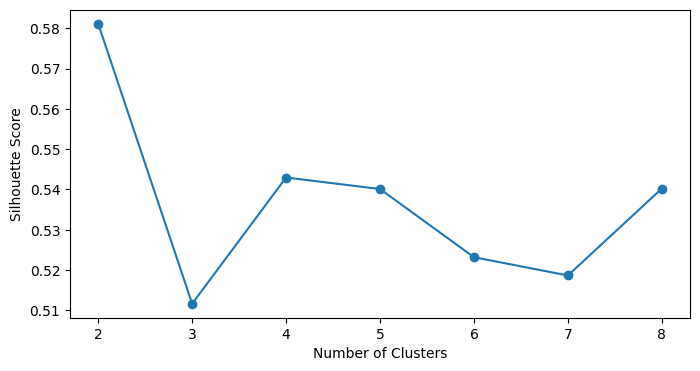

In [40]:
frame = pd.DataFrame({"Cluster" : range(2,9), "Silhouette Score" : sil_scores})
plt.figure(figsize=(8,4))
plt.plot(frame["Cluster"], frame["Silhouette Score"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

It is found that two clusters are needed to make relationship.

In [41]:
kmns = KMeans(n_clusters=2, init = "k-means++", max_iter=300, random_state=42)
y_kmeans = kmns.fit_predict(data)
print(y_kmeans)
center = kmns.cluster_centers_
center


[0 1 0 ... 0 0 0]


array([[3.40469169e+01, 1.03999920e+05],
       [4.13779528e+01, 1.70749915e+05]])

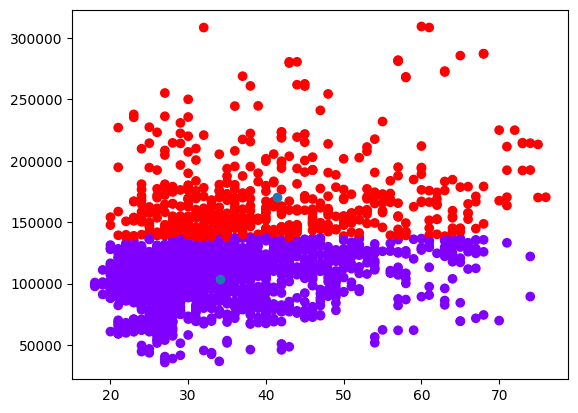

In [43]:
plt.scatter(data.iloc[:,0], data.iloc[:,1], c=y_kmeans, cmap="rainbow")
plt.scatter(center[:,0], center[:,1], marker="o", )

Analyzing

<Axes: xlabel='Age', ylabel='Count'>

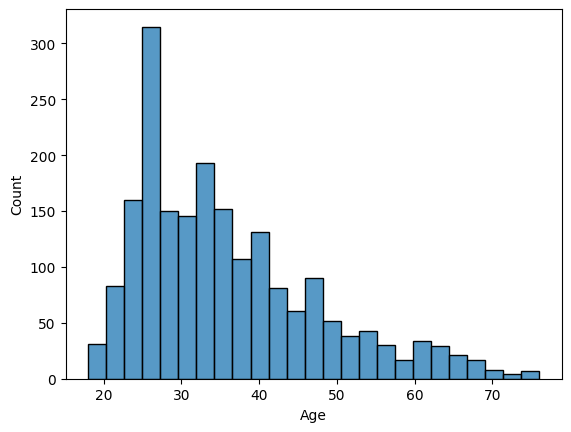

In [51]:
sns.histplot(x=df["Age"])

([<matplotlib.patches.Wedge at 0x782dba1e7890>,
 [Text(0.019005544588348296, 1.099835801051639, '0'),
  Text(-0.7504787845321526, -0.8042273272944306, '1'),
  Text(0.8170738536306174, -0.7364715321811243, '2')],
 [Text(0.010366660684553615, 0.5999104369372575, '49.5%'),
  Text(-0.409352064290265, -0.4386694512515075, '27.2%'),
  Text(0.44567664743488217, -0.40171174482606775, '23.4%')])

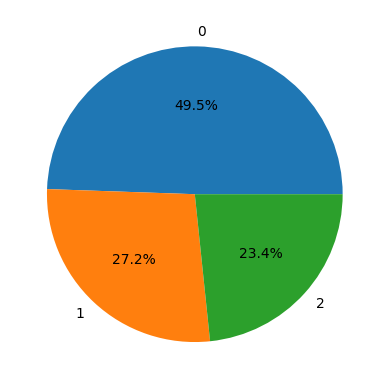

In [52]:
plt.pie(x=df["Settlement size"].value_counts(), labels=df["Settlement size"].value_counts().index, autopct='%1.1f%%')

<Axes: xlabel='Income', ylabel='Count'>

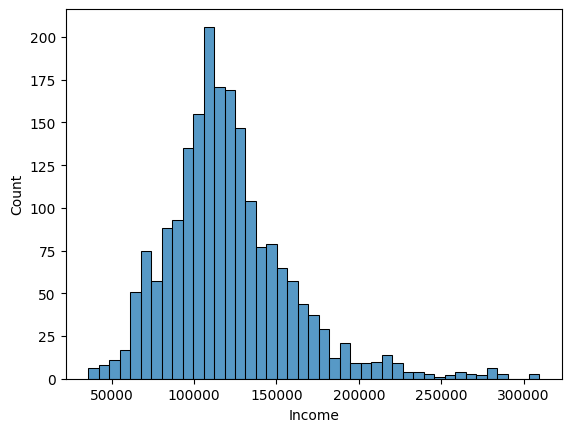

In [53]:
sns.histplot(x=df["Income"])

It is found that the columns age is right distributed showing that most of the dataset ranges from 20 to 30 age.
The pi chart shows that the data set is more from small city "0"
The Income dataset shows that the data is normally distributed.